# Köppen–Geiger a partir do ERA5 (1995–2025)

Reprodução exploratória, com dados modernos do ERA5 (reanalysis-era5-single-levels-monthly-means), do mapa de classificação climática de Köppen apresentado em Alvares et al. (2013), *"Köppen's climate classification map for Brazil"*.

**Área coberta pelos dados baixados (recorte parcial, não o Brasil inteiro):**
lat -14° a -25.5°, lon -53.5° a -39.5° — cobre aproximadamente GO/DF/MS/MG/SP/parte do PR e TO/BA.

**Variáveis:** `2t` (temperatura do ar a 2m) e `tp` (precipitação total), médias mensais, grade 0.1°, jan/1995–dez/2025 (31 anos, 31 > 25 anos usados no artigo original).

**Critérios de classificação:** os mesmos usados no artigo (Köppen 1936), na formalização padrão de Kottek et al. (2006) / Peel et al. (2007), que o próprio Alvares et al. cita como referência para reprodutibilidade.


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import earthkit.data as ekd

GRIB_PATH = "93eefbba64a366960bd916ed34f628a3.grib"
np.set_printoptions(suppress=True)


In [2]:
import geopandas as gpd

# Contorno dos estados brasileiros (fonte: click_that_hood, salvo em data/).
# Simplificado (tolerância em graus) para um traço suave, sem serrilhado de
# vetor de alta resolução -- adequado para sobrepor num mapa em grade ~0.1°.
BR_STATES = gpd.read_file("data/brazil_states.geojson")
BR_STATES["geometry"] = BR_STATES.geometry.simplify(0.03, preserve_topology=True)


def add_state_borders(ax, color="#404040", lw=0.6, alpha=0.75):
    """Desenha o contorno suave dos estados sobre um eixo de mapa já plotado,
    preservando os limites (xlim/ylim) definidos pelos dados climáticos."""
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    BR_STATES.boundary.plot(ax=ax, color=color, linewidth=lw, alpha=alpha, zorder=5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


## 1. Carregar o GRIB com earthkit-data e converter para xarray

In [3]:
source = ekd.from_source("file", GRIB_PATH)
fieldlist = source.to_fieldlist()
ds = fieldlist.to_xarray()
ds = ds.rename({"forecast_reference_time": "time"})

# Unidades: 2t vem em Kelvin; tp vem como taxa média diária em m/dia
ds["t2m_c"] = ds["2t"] - 273.15
days_in_month = ds["time"].dt.days_in_month
ds["precip_mm"] = ds["tp"] * days_in_month * 1000.0

ds["t2m_c"].attrs["units"] = "degC"
ds["precip_mm"].attrs["units"] = "mm/month"

ds


<xarray.Dataset> Size: 195MB
Dimensions:    (time: 372, latitude: 116, longitude: 141)
Coordinates:
  * time       (time) datetime64[us] 3kB 1995-01-01 1995-02-01 ... 2025-12-01
  * latitude   (latitude) float64 928B -14.0 -14.1 -14.2 ... -25.3 -25.4 -25.5
  * longitude  (longitude) float64 1kB -53.5 -53.4 -53.3 ... -39.7 -39.6 -39.5
Data variables:
    2t         (time, latitude, longitude) float64 49MB 298.1 298.2 ... nan nan
    tp         (time, latitude, longitude) float64 49MB ...
    t2m_c      (time, latitude, longitude) float64 49MB 24.93 25.05 ... nan nan
    precip_mm  (time, latitude, longitude) float64 49MB 279.0 283.4 ... nan nan
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## 2. Análise exploratória

Antes de classificar, vamos olhar a série temporal e a climatologia (1995–2025) de temperatura e precipitação nessa região.

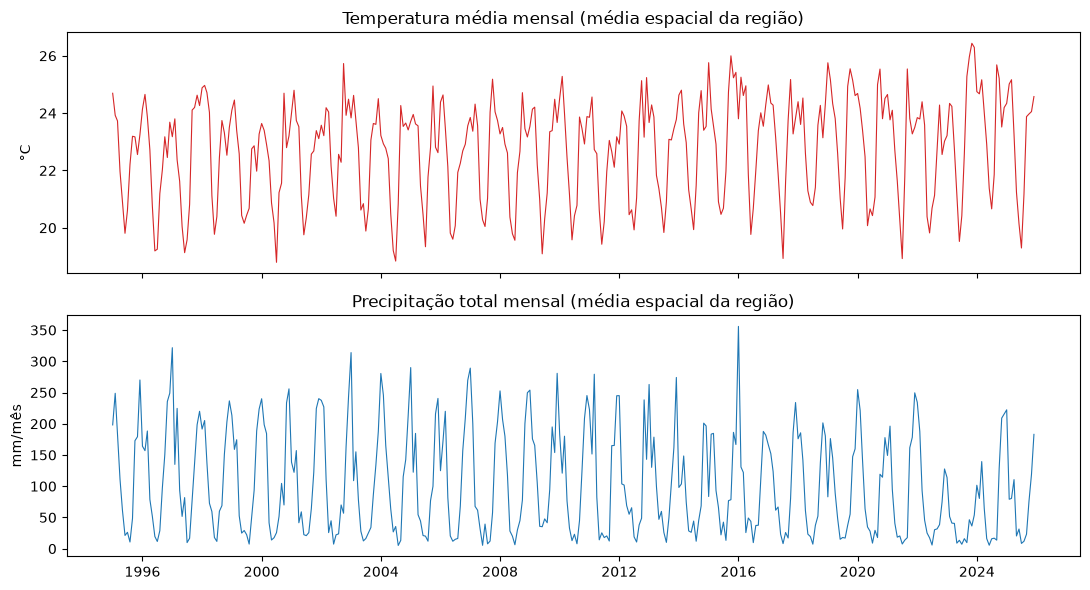

In [4]:
# Série temporal média espacial (toda a região) -- verifica tendência/ruído ao longo dos 31 anos
regional_t = ds["t2m_c"].mean(dim=["latitude", "longitude"])
regional_p = ds["precip_mm"].mean(dim=["latitude", "longitude"])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
regional_t.plot(ax=axes[0], color="tab:red", lw=0.8)
axes[0].set_title("Temperatura média mensal (média espacial da região)")
axes[0].set_ylabel("°C")
axes[0].set_xlabel("")

regional_p.plot(ax=axes[1], color="tab:blue", lw=0.8)
axes[1].set_title("Precipitação total mensal (média espacial da região)")
axes[1].set_ylabel("mm/mês")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


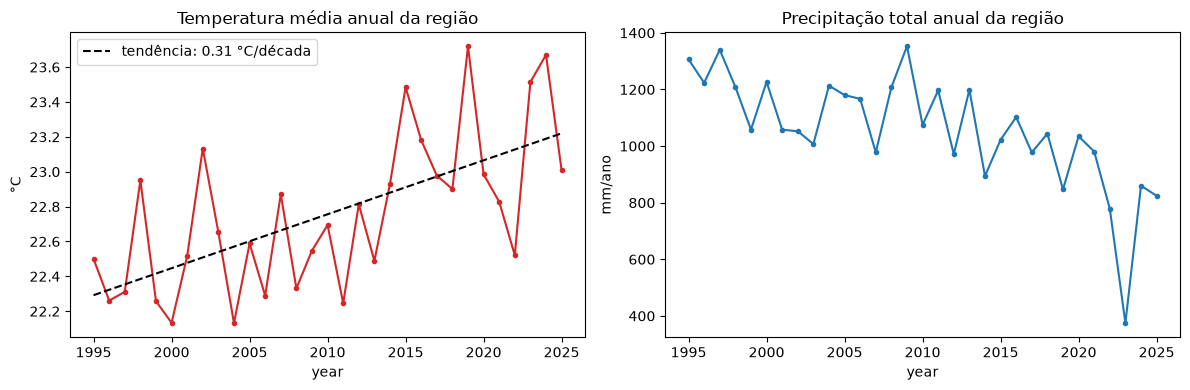

In [5]:
# Tendência de aquecimento: média anual de temperatura, ano a ano
annual_t = ds["t2m_c"].groupby("time.year").mean(dim=["time", "latitude", "longitude"])
annual_p = ds["precip_mm"].groupby("time.year").sum(dim="time").mean(dim=["latitude", "longitude"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
annual_t.plot(ax=axes[0], marker="o", ms=3, color="tab:red")
z = np.polyfit(annual_t["year"], annual_t.values, 1)
axes[0].plot(annual_t["year"], np.polyval(z, annual_t["year"]), "k--",
             label=f"tendência: {z[0]*10:.2f} °C/década")
axes[0].set_title("Temperatura média anual da região")
axes[0].set_ylabel("°C")
axes[0].legend()

annual_p.plot(ax=axes[1], marker="o", ms=3, color="tab:blue")
axes[1].set_title("Precipitação total anual da região")
axes[1].set_ylabel("mm/ano")

plt.tight_layout()
plt.show()


## 3. Climatologia mensal (1995–2025)

Para cada célula da grade e cada mês do ano (jan..dez), calculamos a média dos 31 anos. É essa climatologia (12 valores de T e 12 de P por pixel) que alimenta as regras de Köppen — exatamente como o artigo original usa normais climatológicas (>25 anos) por estação.

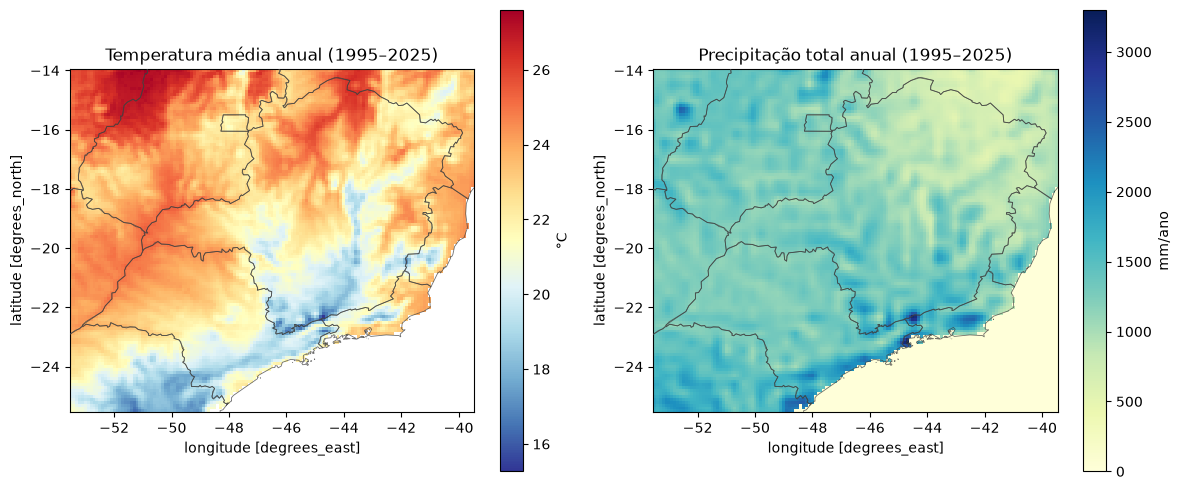

In [6]:
t_clim = ds["t2m_c"].groupby("time.month").mean(dim="time")      # (month, lat, lon) - media das medias mensais
p_clim = ds["precip_mm"].groupby("time.month").mean(dim="time")  # (month, lat, lon) - media dos totais mensais

t_clim = t_clim.sortby("month")
p_clim = p_clim.sortby("month")

mat_map = t_clim.mean(dim="month")   # temperatura media anual
map_map = p_clim.sum(dim="month")    # precipitacao total anual (normal climatologica)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mat_map.plot(ax=axes[0], cmap="RdYlBu_r", cbar_kwargs={"label": "°C"})
axes[0].set_title("Temperatura média anual (1995–2025)")
add_state_borders(axes[0])

map_map.plot(ax=axes[1], cmap="YlGnBu", cbar_kwargs={"label": "mm/ano"})
axes[1].set_title("Precipitação total anual (1995–2025)")
add_state_borders(axes[1])

plt.tight_layout()
plt.show()


## 4. Algoritmo de classificação de Köppen–Geiger

Implementação vetorizada (numpy) das regras da Tabela 1 do artigo (idênticas a Kottek et al. 2006 / Peel et al. 2007). Toda a região está no hemisfério sul, então verão = out–mar e inverno = abr–set (índices de mês 0=jan .. 11=dez).

Ordem de prioridade na avaliação (segue o artigo/Peel et al. 2007): **B (árido) → A (tropical) → E (polar) → C/D (temperado/continental)**.

In [7]:
def koppen_classify(T, P, summer_idx=(9, 10, 11, 0, 1, 2), winter_idx=(3, 4, 5, 6, 7, 8)):
    """
    T, P: arrays (12, lat, lon) com climatologia mensal de temperatura (°C) e
          precipitacao (mm/mes), mes 0 = Janeiro ... mes 11 = Dezembro.
    summer_idx / winter_idx: indices de mes (0-based) do semestre de verao e inverno
          para o hemisferio da regiao (default: hemisferio sul).
    Retorna: array 2D de strings com o codigo Koppen (ex: 'Aw', 'Cfa', 'BSh', ...).
             Celulas sem dado valido (oceano/mascara) recebem 'NA'.
    """
    T = np.asarray(T)
    P = np.asarray(P)

    # celulas com qualquer mes faltante (ex: oceano dentro da bbox) ficam de fora
    valid = ~(np.isnan(T).any(axis=0) | np.isnan(P).any(axis=0))

    MAT = T.mean(axis=0)
    MAP = P.sum(axis=0)
    Tcold = T.min(axis=0)
    Thot = T.max(axis=0)
    Pdry = P.min(axis=0)
    TM10 = (T > 10).sum(axis=0)

    Psum = P[list(summer_idx)]
    Pwin = P[list(winter_idx)]
    Psdry, Pswet = Psum.min(axis=0), Psum.max(axis=0)
    Pwdry, Pwwet = Pwin.min(axis=0), Pwin.max(axis=0)

    frac_win = Pwin.sum(axis=0) / MAP
    frac_sum = Psum.sum(axis=0) / MAP
    Pthresh = np.where(frac_win >= 0.7, 2 * MAT,
                        np.where(frac_sum >= 0.7, 2 * MAT + 28, 2 * MAT + 14))

    code = np.full(MAT.shape, "NA", dtype="<U3")
    unresolved = valid.copy()

    # --- B: clima arido (checado primeiro, tem prioridade sobre A/C/D) ---
    is_B = unresolved & (MAP < 10 * Pthresh)
    is_h = MAT >= 18
    is_arid = is_B & (MAP < 5 * Pthresh)
    is_semiarid = is_B & ~is_arid
    code[is_arid & is_h] = "BWh"
    code[is_arid & ~is_h] = "BWk"
    code[is_semiarid & is_h] = "BSh"
    code[is_semiarid & ~is_h] = "BSk"
    unresolved &= ~is_B

    # --- A: clima tropical ---
    is_A = unresolved & (Tcold >= 18)
    is_Af = is_A & (Pdry >= 60)
    is_Am = is_A & ~is_Af & (Pdry >= (100 - MAP / 25))
    is_Aws = is_A & ~is_Af & ~is_Am
    dry_month = np.argmin(P, axis=0)
    dry_in_summer = np.isin(dry_month, list(summer_idx))
    is_As = is_Aws & dry_in_summer
    is_Aw = is_Aws & ~dry_in_summer
    code[is_Af] = "Af"
    code[is_Am] = "Am"
    code[is_As] = "As"
    code[is_Aw] = "Aw"
    unresolved &= ~is_A

    # --- E: clima polar ---
    is_E = unresolved & (Thot < 10)
    code[is_E & (Thot >= 0)] = "ET"
    code[is_E & (Thot < 0)] = "EF"
    unresolved &= ~is_E

    # --- C / D: temperado / continental ---
    is_CD = unresolved
    is_D = is_CD & (Tcold < -3)
    is_C = is_CD & ~is_D

    is_f = is_CD & (Pdry > 40)
    is_w = is_CD & ~is_f & (Pswet >= 10 * Pwdry)
    is_s = is_CD & ~is_f & ~is_w & (Pwwet >= 3 * Psdry)
    # fallback: quando nao se enquadra perfeitamente em w/s mas Pdry<=40, classifica como f
    # (evita celulas sem classificacao por empates nas condicoes de fronteira)
    is_unclassified_rain = is_CD & ~is_f & ~is_w & ~is_s
    is_f = is_f | is_unclassified_rain

    is_a = is_CD & (Thot >= 22)
    is_b = is_CD & (Thot < 22) & (TM10 >= 4)
    is_c = is_CD & (Thot < 22) & (TM10 < 4) & (Tcold >= -38)
    is_d = is_CD & (Tcold < -38)

    for zone_mask, zone_letter in [(is_C, "C"), (is_D, "D")]:
        for rain_mask, rain_letter in [(is_f, "f"), (is_w, "w"), (is_s, "s")]:
            m = zone_mask & rain_mask
            code[m & is_a] = zone_letter + rain_letter + "a"
            code[m & is_b] = zone_letter + rain_letter + "b"
            code[m & is_c] = zone_letter + rain_letter + "c"
            if zone_letter == "D":
                code[m & is_d] = zone_letter + rain_letter + "d"

    assert (code[~valid] == "NA").all()
    assert (code[valid] != "NA").all(), "existem celulas com dado valido que nao foram classificadas"
    return code, valid


T_arr = t_clim.transpose("month", "latitude", "longitude").values
P_arr = p_clim.transpose("month", "latitude", "longitude").values
koppen_codes, valid_mask = koppen_classify(T_arr, P_arr)

print(f"Células válidas (terra): {valid_mask.sum()} / {valid_mask.size} "
      f"({100*valid_mask.sum()/valid_mask.size:.1f}%) -- o resto é oceano dentro da bbox baixada")

unique, counts = np.unique(koppen_codes[valid_mask], return_counts=True)
pd.DataFrame({"climate": unique, "n_pixels": counts, "%": 100 * counts / counts.sum()}).sort_values("%", ascending=False)


Células válidas (terra): 13966 / 16356 (85.4%) -- o resto é oceano dentro da bbox baixada


,climate,n_pixels,%
2,Aw,9639,69.017614
4,Cfa,1373,9.831018
6,Cwa,825,5.907203
3,BSh,789,5.649434
5,Cfb,602,4.310468
7,Cwb,465,3.329515
1,Am,155,1.109838
0,Af,118,0.844909


### 4.1 Verificação do algoritmo com perfis sintéticos

Antes de confiar no mapa, testamos a função com perfis mensais construídos à mão para cada tipo climático — incluindo tipos que **não** ocorrem nessa região (Cwc, Csa, Csb, ET, EF, BWh), para garantir que as regras das zonas D/E e dos subtipos raros também estão corretas e não só as que "por sorte" aparecem nos dados.

In [8]:
def _classify_profile(T12, P12):
    """Classifica um unico perfil mensal (listas de 12 valores)."""
    T = np.array(T12, dtype=float).reshape(12, 1, 1)
    P = np.array(P12, dtype=float).reshape(12, 1, 1)
    return koppen_classify(T, P)[0][0, 0]


# Perfis sinteticos (hemisferio sul: verao = out-mar, inverno = abr-set).
# Jan .......................................................... Dez
CASOS_TESTE = {
    "Af":  ([27] * 12,
            [280, 280, 300, 300, 300, 160, 120, 80, 100, 140, 180, 220]),
    "Am":  ([27] * 12,
            [300, 350, 400, 400, 380, 250, 130, 40, 15, 30, 80, 150]),
    "Aw":  ([26] * 12,
            [280, 260, 270, 150, 40, 2, 1, 5, 40, 180, 230, 250]),
    "As":  ([26] * 12,          # seca no verao (set-dez), chuva no inverno
            [60, 90, 150, 200, 250, 280, 220, 110, 30, 20, 25, 40]),
    "BSh": ([26] * 12,
            [80, 110, 130, 60, 20, 5, 2, 1, 2, 10, 30, 60]),
    "BWh": ([28] * 12,
            [5, 5, 3, 2, 1, 0, 0, 0, 1, 2, 3, 5]),
    "Cfa": ([24, 24, 22, 19, 16, 13, 13, 14, 16, 19, 21, 23],
            [120, 130, 130, 140, 120, 140, 130, 140, 140, 120, 110, 120]),
    "Cfb": ([20.5, 20, 19, 17, 14, 13, 13, 14, 15, 17, 18, 20],
            [170, 150, 130, 90, 100, 110, 100, 80, 120, 140, 120, 150]),
    "Cwa": ([23.5, 23.5, 23, 21, 19, 17.5, 17.5, 19, 21, 22, 23, 23],
            [280, 200, 160, 60, 40, 20, 15, 20, 50, 130, 180, 260]),
    "Cwb": ([21.5, 21.5, 21, 20, 18, 16.5, 15.5, 17, 19, 20, 21, 21],
            [300, 180, 150, 60, 25, 12, 10, 12, 35, 120, 220, 300]),
    "Cwc": ([11.5, 11, 9.5, 8, 6, 4.5, 4.5, 6, 8, 9.5, 10, 11],   # so 3 meses > 10 C
            [200, 160, 150, 60, 40, 20, 15, 25, 60, 140, 180, 210]),
    "Csa": ([22.7, 22.5, 22, 21, 19, 18, 17.5, 17.9, 19, 20.5, 22, 22.7],
            [40, 60, 80, 120, 140, 130, 100, 50, 25, 20, 20, 25]),
    "Csb": ([21.5, 21.3, 21, 20, 19, 17.5, 17, 17.5, 18.5, 19.5, 20.5, 21.5],
            [40, 60, 80, 120, 140, 130, 100, 50, 25, 20, 20, 25]),
    "ET":  ([5, 5, 4, 2, 0, -2, -3, -1, 1, 3, 4, 5], [50] * 12),
    "EF":  ([-5] * 12, [30] * 12),
}

falhas = []
for esperado, (T12, P12) in CASOS_TESTE.items():
    obtido = _classify_profile(T12, P12)
    if obtido != esperado:
        falhas.append((esperado, obtido))
    print(f"{'OK   ' if obtido == esperado else 'FALHA'} esperado={esperado:<4} obtido={obtido:<4}"
          f"  Tcold={min(T12):5.1f}  Thot={max(T12):5.1f}  MAP={sum(P12):5.0f}mm  Pdry={min(P12):3.0f}mm")

assert not falhas, f"casos que falharam: {falhas}"
print(f"\n{len(CASOS_TESTE)}/{len(CASOS_TESTE)} casos corretos")


OK    esperado=Af   obtido=Af    Tcold= 27.0  Thot= 27.0  MAP= 2460mm  Pdry= 80mm
OK    esperado=Am   obtido=Am    Tcold= 27.0  Thot= 27.0  MAP= 2525mm  Pdry= 15mm
OK    esperado=Aw   obtido=Aw    Tcold= 26.0  Thot= 26.0  MAP= 1708mm  Pdry=  1mm
OK    esperado=As   obtido=As    Tcold= 26.0  Thot= 26.0  MAP= 1475mm  Pdry= 20mm
OK    esperado=BSh  obtido=BSh   Tcold= 26.0  Thot= 26.0  MAP=  510mm  Pdry=  1mm
OK    esperado=BWh  obtido=BWh   Tcold= 28.0  Thot= 28.0  MAP=   27mm  Pdry=  0mm
OK    esperado=Cfa  obtido=Cfa   Tcold= 13.0  Thot= 24.0  MAP= 1540mm  Pdry=110mm
OK    esperado=Cfb  obtido=Cfb   Tcold= 13.0  Thot= 20.5  MAP= 1460mm  Pdry= 80mm
OK    esperado=Cwa  obtido=Cwa   Tcold= 17.5  Thot= 23.5  MAP= 1415mm  Pdry= 15mm
OK    esperado=Cwb  obtido=Cwb   Tcold= 15.5  Thot= 21.5  MAP= 1424mm  Pdry= 10mm
OK    esperado=Cwc  obtido=Cwc   Tcold=  4.5  Thot= 11.5  MAP= 1260mm  Pdry= 15mm
OK    esperado=Csa  obtido=Csa   Tcold= 17.5  Thot= 22.7  MAP=  810mm  Pdry= 20mm
OK    esperado=C

## 5. Mapa de classificação de Köppen (ERA5, 1995–2025)

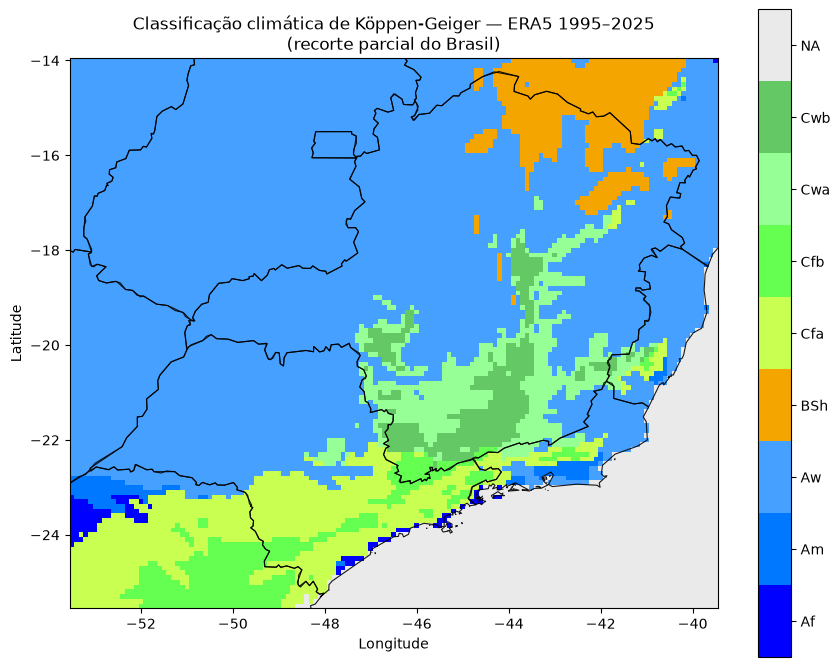

In [9]:
# Paleta no padrão Köppen-Geiger (mesmo esquema de cores sugerido por Peel et al. 2007,
# usado no mapa original do artigo). NA = oceano/sem dado dentro da bbox.
KOPPEN_COLORS = {
    "Af": "#0000FF", "Am": "#0078FF", "Aw": "#46A0FF", "As": "#64B4FF",
    "BWh": "#FF0000", "BWk": "#FFA0A0", "BSh": "#F5A500", "BSk": "#FFDC64",
    "Csa": "#FFFF00", "Csb": "#C8C800", "Csc": "#969600",
    "Cwa": "#96FF96", "Cwb": "#64C864", "Cwc": "#329632",
    "Cfa": "#C8FF50", "Cfb": "#64FF50", "Cfc": "#32C800",
    "Dsa": "#FF00FF", "Dsb": "#C800C8", "Dsc": "#963296", "Dsd": "#966496",
    "Dwa": "#ABB1FF", "Dwb": "#5A77DB", "Dwc": "#4C51B5", "Dwd": "#320087",
    "Dfa": "#00FFFF", "Dfb": "#37C8FF", "Dfc": "#007D7D", "Dfd": "#00465F",
    "ET": "#B3B3B3", "EF": "#696969",
    "NA": "#EAEAEA",
}

codes_present = [c for c in sorted(np.unique(koppen_codes)) ]
cmap = ListedColormap([KOPPEN_COLORS.get(c, "#FF00FF") for c in codes_present])
code_to_int = {c: i for i, c in enumerate(codes_present)}
int_grid = np.vectorize(code_to_int.get)(koppen_codes)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(
    p_clim["longitude"], p_clim["latitude"], int_grid,
    cmap=cmap, vmin=-0.5, vmax=len(codes_present) - 0.5, shading="auto",
)
ax.set_title("Classificação climática de Köppen-Geiger — ERA5 1995–2025\n(recorte parcial do Brasil)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
add_state_borders(ax, color="black", lw=0.8, alpha=0.9)

cbar = fig.colorbar(im, ax=ax, ticks=range(len(codes_present)))
cbar.ax.set_yticklabels(codes_present)

plt.tight_layout()
plt.show()


### 5.1 Validação contra o artigo original

O algoritmo estar correto não garante que o **resultado** bata com o artigo — os dados de entrada são outros (ERA5 1995–2025 vs. 2.950 estações 1950–1990). Aqui comparamos, ponto a ponto, as localidades típicas da Figura 8 do artigo que caem dentro da bbox.

In [10]:
lats, lons = ds["latitude"].values, ds["longitude"].values
t_vals = t_clim.transpose("month", "latitude", "longitude").values
p_vals = p_clim.transpose("month", "latitude", "longitude").values


def sonda(lat, lon):
    i = int(np.abs(lats - lat).argmin())
    j = int(np.abs(lons - lon).argmin())
    return koppen_codes[i, j], p_vals[:, i, j].sum(), t_vals[:, i, j].mean()


# localidades tipicas do artigo (Fig. 8) que caem dentro da bbox, com a
# classificacao e a precipitacao anual reportadas por Alvares et al. (2013)
REFERENCIA = [
    ("Ribeirão Preto (SP)", -21.18, -47.81, "Cwa", 1400),
    ("Belo Horizonte (MG)", -19.92, -43.94, "Cwb", 1500),
    ("Pico da Bandeira",    -20.43, -41.79, "Cwc", 1300),
    ("Curitiba (PR)",       -25.43, -49.27, "Cfb", 1550),
    ("Brasília (DF)",       -15.78, -47.93, "Aw",  1500),
]

linhas = []
for nome, la, lo, kp_artigo, p_artigo in REFERENCIA:
    kp_era5, p_era5, t_era5 = sonda(la, lo)
    linhas.append({
        "local": nome,
        "Köppen artigo": kp_artigo,
        "Köppen ERA5": kp_era5,
        "bate?": "sim" if kp_era5 == kp_artigo else "NÃO",
        "P artigo (mm)": p_artigo,
        "P ERA5 (mm)": round(p_era5),
        "viés P (%)": round(100 * (p_era5 - p_artigo) / p_artigo),
        "T ERA5 (°C)": round(t_era5, 1),
    })

pd.DataFrame(linhas)


,local,Köppen artigo,Köppen ERA5,bate?,P artigo (mm),P ERA5 (mm),viés P (%),T ERA5 (°C)
0,Ribeirão Preto (SP),Cwa,Aw,NÃO,1400,1233,-12,22.7
1,Belo Horizonte (MG),Cwb,Cwa,NÃO,1500,924,-38,20.8
2,Pico da Bandeira,Cwc,Cwb,NÃO,1300,1254,-4,17.4
3,Curitiba (PR),Cfb,Cfb,sim,1550,1513,-2,17.2
4,Brasília (DF),Aw,Aw,sim,1500,1262,-16,21.9


In [11]:
# O artigo afirma explicitamente que NAO existe clima BSh em Minas Gerais
# (o ponto mais ao sul seria Piripa/BA, ~15S). Onde o ERA5 coloca BSh?
LAT2D, LON2D = np.meshgrid(lats, lons, indexing="ij")
bsh = (koppen_codes == "BSh") & valid_mask

print(f"Células BSh: {bsh.sum()}")
print(f"  latitude : {LAT2D[bsh].min():.1f}° a {LAT2D[bsh].max():.1f}°")
print(f"  longitude: {LON2D[bsh].min():.1f}° a {LON2D[bsh].max():.1f}°")
for lim in (-15, -16, -17, -18):
    print(f"  ao sul de {abs(lim)}°S (≈ norte de MG, onde o artigo diz não haver BSh): "
          f"{(bsh & (LAT2D < lim)).sum()} células")

# Quao marginal e essa classificacao? Distancia ate o limiar 10*Pthreshold
MAT = t_vals.mean(axis=0)
MAP = p_vals.sum(axis=0)
summer_idx, winter_idx = [9, 10, 11, 0, 1, 2], [3, 4, 5, 6, 7, 8]
frac_win = p_vals[winter_idx].sum(axis=0) / MAP
frac_sum = p_vals[summer_idx].sum(axis=0) / MAP
Pth = np.where(frac_win >= 0.7, 2 * MAT, np.where(frac_sum >= 0.7, 2 * MAT + 28, 2 * MAT + 14))
margem = MAP - 10 * Pth   # < 0 => classificado como B

print(f"\nMargem até a fronteira B (MAP - 10·Pthreshold) nas células BSh:")
print(f"  mediana {np.median(margem[bsh]):.0f} mm | "
      f"células a menos de 50 mm da fronteira: {(np.abs(margem[bsh]) < 50).sum()} de {bsh.sum()}")
print(f"\nSensibilidade geral das fronteiras:")
print(f"  células na fronteira A/C (Tcold entre 17.5 e 18.5 °C): "
      f"{((t_vals.min(axis=0) > 17.5) & (t_vals.min(axis=0) < 18.5) & valid_mask).sum()}")
print(f"  células na fronteira B  (MAP entre 9× e 11× Pthreshold): "
      f"{((MAP > 9 * Pth) & (MAP < 11 * Pth) & valid_mask).sum()}")


Células BSh: 789
  latitude : -19.1° a -14.0°
  longitude: -44.9° a -40.0°
  ao sul de 15°S (≈ norte de MG, onde o artigo diz não haver BSh): 378 células
  ao sul de 16°S (≈ norte de MG, onde o artigo diz não haver BSh): 132 células
  ao sul de 17°S (≈ norte de MG, onde o artigo diz não haver BSh): 24 células
  ao sul de 18°S (≈ norte de MG, onde o artigo diz não haver BSh): 8 células

Margem até a fronteira B (MAP - 10·Pthreshold) nas células BSh:
  mediana -89 mm | células a menos de 50 mm da fronteira: 223 de 789

Sensibilidade geral das fronteiras:
  células na fronteira A/C (Tcold entre 17.5 e 18.5 °C): 1377
  células na fronteira B  (MAP entre 9× e 11× Pthreshold): 742


## 6. Sensibilidade temporal: 1995–2010 vs. 2011–2025

Uma vantagem de ter 31 anos de ERA5 é poder checar se a classificação de Köppen está migrando ao longo do tempo (ex: célula que era `Aw` virar `BSh`), o que o artigo original (limitado a normais 1950–1990 de estações) não conseguia fazer.

Células que mudaram de tipo climático entre 1995-2010 e 2011-2025: 2261 / 13966 (16.2%)
Aw -> BSh     858
Cwa -> Aw     332
Am -> Aw      297
Cfb -> Cfa    176
Cfa -> Aw     165
Cwb -> Cwa    149
Af -> Am       72
Cwa -> Cfa     47
Af -> Aw       45
Cfa -> Am      24
Name: count, dtype: int64


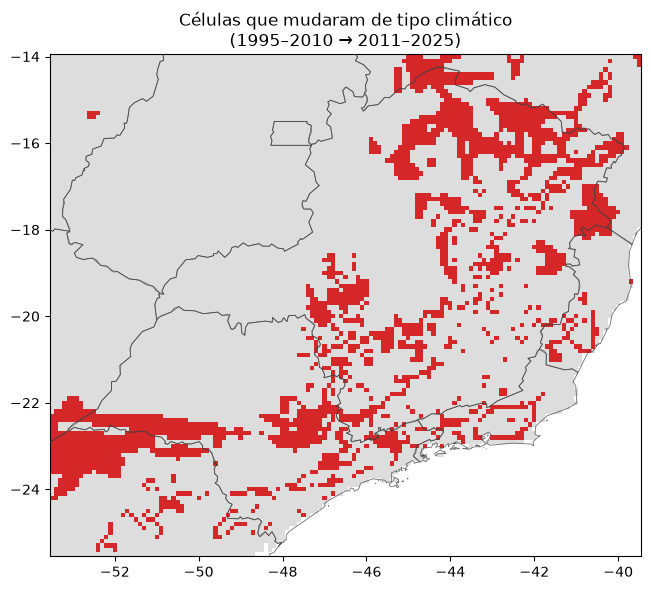

In [12]:
def climatology_for_period(ds, y0, y1):
    sub = ds.sel(time=slice(f"{y0}-01-01", f"{y1}-12-31"))
    t = sub["t2m_c"].groupby("time.month").mean(dim="time").sortby("month")
    p = sub["precip_mm"].groupby("time.month").mean(dim="time").sortby("month")
    T = t.transpose("month", "latitude", "longitude").values
    P = p.transpose("month", "latitude", "longitude").values
    return T, P, koppen_classify(T, P)

T_early, P_early, (codes_early, valid_early) = climatology_for_period(ds, 1995, 2010)
T_late, P_late, (codes_late, valid_late) = climatology_for_period(ds, 2011, 2025)

both_valid = valid_early & valid_late
changed = both_valid & (codes_early != codes_late)
print(f"Células que mudaram de tipo climático entre 1995-2010 e 2011-2025: "
      f"{changed.sum()} / {both_valid.sum()} ({100*changed.sum()/both_valid.sum():.1f}%)")

transitions = pd.Series(
    [f"{a} -> {b}" for a, b in zip(codes_early[changed], codes_late[changed])]
).value_counts()
print(transitions.head(10))

fig, ax = plt.subplots(figsize=(8, 6))
diff_plot = np.where(changed, 1, np.where(both_valid, 0, np.nan))
ax.pcolormesh(p_clim["longitude"], p_clim["latitude"], diff_plot,
              cmap=ListedColormap(["#dddddd", "#d62728"]), vmin=0, vmax=1, shading="auto")
ax.set_title("Células que mudaram de tipo climático\n(1995–2010 → 2011–2025)")
ax.set_aspect("equal")
add_state_borders(ax)
plt.tight_layout()
plt.show()


In [13]:
# A transicao dominante (Aw -> BSh) e sinal de secamento real ou artefato do limiar?
# Note que Pthreshold = 2*MAT (+14/+28), entao o simples AQUECIMENTO ja eleva o limiar
# e empurra celulas para a zona B mesmo com chuva constante. Vamos decompor.
def _pthreshold(T, P):
    MAT = T.mean(axis=0)
    MAP = P.sum(axis=0)
    fw = P[winter_idx].sum(axis=0) / MAP
    fs = P[summer_idx].sum(axis=0) / MAP
    return MAT, MAP, np.where(fw >= 0.7, 2 * MAT, np.where(fs >= 0.7, 2 * MAT + 28, 2 * MAT + 14))

MAT_e, MAP_e, Pth_e = _pthreshold(T_early, P_early)
MAT_l, MAP_l, Pth_l = _pthreshold(T_late, P_late)

trans = both_valid & (codes_early == "Aw") & (codes_late == "BSh")
d_map = MAP_l[trans].mean() - MAP_e[trans].mean()
d_thr = 10 * (Pth_l[trans].mean() - Pth_e[trans].mean())

print(f"Células Aw -> BSh: {trans.sum()}\n")
print(f"  precipitação anual : {MAP_e[trans].mean():7.1f} -> {MAP_l[trans].mean():7.1f} mm  ({d_map:+.1f} mm)")
print(f"  temperatura média  : {MAT_e[trans].mean():7.2f} -> {MAT_l[trans].mean():7.2f} °C  "
      f"({MAT_l[trans].mean()-MAT_e[trans].mean():+.2f} °C)")
print(f"  limiar 10·Pthresh  : {10*Pth_e[trans].mean():7.1f} -> {10*Pth_l[trans].mean():7.1f} mm  ({d_thr:+.1f} mm)")
print(f"\n  Contribuição para a mudança de classe:")
print(f"    queda de precipitação          : {abs(d_map):6.1f} mm  ({100*abs(d_map)/(abs(d_map)+abs(d_thr)):.0f}%)")
print(f"    elevação do limiar (aquecimento): {abs(d_thr):6.1f} mm  ({100*abs(d_thr)/(abs(d_map)+abs(d_thr)):.0f}%)")

margem_late = MAP_l[trans] - 10 * Pth_l[trans]
marginais = (np.abs(margem_late) < 50).sum()
print(f"\n  Mas atenção: {marginais} das {trans.sum()} células ({100*marginais/trans.sum():.0f}%) "
      f"estão a menos de 50 mm da fronteira,")
print(f"  ou seja, a reclassificação é marginal e poderia reverter com poucos anos diferentes.")


Células Aw -> BSh: 858

  precipitação anual :   856.6 ->   695.2 mm  (-161.4 mm)
  temperatura média  :   23.50 ->   24.09 °C  (+0.60 °C)
  limiar 10·Pthresh  :   750.0 ->   761.9 mm  (+11.9 mm)

  Contribuição para a mudança de classe:
    queda de precipitação          :  161.4 mm  (93%)
    elevação do limiar (aquecimento):   11.9 mm  (7%)

  Mas atenção: 387 das 858 células (45%) estão a menos de 50 mm da fronteira,
  ou seja, a reclassificação é marginal e poderia reverter com poucos anos diferentes.


## 7. Ressalvas metodológicas

O algoritmo passa em 15/15 testes sintéticos (seção 4.1), então as divergências abaixo vêm dos **dados de entrada**, não das regras.

**Limitações dos dados**

- **Área parcial**: a bbox baixada (lat -14/-25.5, lon -53.5/-39.5) cobre só GO/DF/MS/MG/SP/parte do PR/TO/BA — não o Brasil inteiro do artigo. Para o mapa completo, refazer o request com `area=[6, -74, -34, -34]` (ver `cds_request.py`).
- **Resolução espacial**: ERA5 tem grade nativa de ~31 km (aqui reamostrada a 0.1°); o artigo chega a 1 ha via krigagem de 2.950 estações + modelo de temperatura por altitude. Consequência direta: **Pico da Bandeira sai como Cwb em vez de Cwc**, porque o ERA5 estima 17 °C onde a temperatura real é 9,4 °C — o pico de 2.890 m simplesmente não existe numa grade de ~11 km. Todo o Cwc do artigo (só 3 sítios no Brasil, todos em picos) é invisível nessa resolução.
- **Viés seco do ERA5 na região**: nas localidades de referência o ERA5 subestima a precipitação anual em ~12–38%. Isso empurra células para classes mais secas e é a explicação mais provável para o BSh aparecer no norte de MG (ver abaixo).
- **Reanálise vs. observação**: ERA5 assimila modelo + observações; não é medição direta como as estações do artigo. O viés é maior em precipitação convectiva, justamente o regime dominante aqui.

**Divergências em relação ao artigo (e por quê)**

- **BSh no norte de Minas Gerais**: o artigo afirma explicitamente que *não há* BSh em MG (o ponto mais ao sul seria Piripá/BA, ~15°S). Nosso mapa coloca BSh até ~19°S, no vale do São Francisco. Vale notar que **Sparovek et al. (2007) e Sá Junior et al. (2012) também encontraram BSh no norte de MG** — ou seja, nosso resultado concorda com esses dois e discorda de Alvares et al. Parte disso é viés seco do ERA5, parte pode ser secamento real desde a linha de base 1950–1990.
- **Ribeirão Preto: Cwa → Aw** e **Belo Horizonte: Cwb → Cwa**. Ambas são mudanças de *uma* letra através de uma fronteira de temperatura (Tcold = 18 °C para A/C; Thot = 22 °C para a/b). Há 1.377 células com Tcold entre 17,5 e 18,5 °C — quase 10% da área está a meio grau de mudar de zona. Aquecimento real entre os períodos + suavização do relevo pelo ERA5 explicam a direção da mudança.
- **`As` não aparece** (0 células), embora o artigo mapeie As no norte de MG. O As do artigo concentra-se no Nordeste, fora da bbox; na porção de MG a diferença cai de novo na sensibilidade da fronteira.

**Sobre a mudança temporal (seção 6)**

- Os 16,2% de células que mudam de classe entre 1995–2010 e 2011–2025 são dominados por `Aw → BSh`, e a decomposição mostra que ~93% do efeito vem de queda de precipitação (−161 mm) e só ~7% da elevação do limiar pelo aquecimento. **Porém**, ~45% dessas células estão a menos de 50 mm da fronteira, e a janela 2011–2025 inclui a seca severa de 2012–2017 no São Francisco. Interpretar como "episódio de seca capturado pela classificação", não como mudança climática consolidada.

## 8. Mapa de Köppen — apenas o período 2011–2025

Mesma paleta e critério da Seção 5, mas usando só a climatologia mais recente
(`codes_late`, já calculada na Seção 6) em vez da climatologia dos 31 anos inteiros.
Serve para comparar diretamente com o mapa da Seção 5 e ver o efeito da janela
temporal mais curta e mais recente na distribuição espacial dos tipos climáticos.

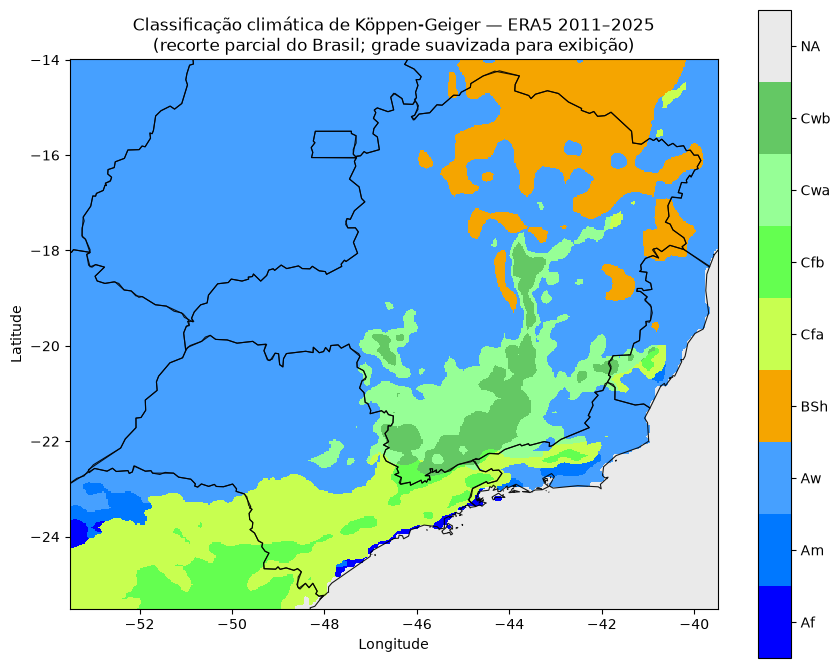

,climate,n_pixels,%
2,Aw,9402,67.320636
4,Cfa,1347,9.644852
3,BSh,1345,9.630531
6,Cwa,782,5.599313
5,Cfb,488,3.494200
7,Cwb,409,2.928541
1,Am,134,0.959473
0,Af,59,0.422455


In [14]:
# Suaviza (interpola) a climatologia 2011-2025 apenas para reduzir o aspecto "pixelado"
# dos blocos de ~11 km no mapa. Isso NAO cria informacao nova -- e so interpolacao
# bilinear entre os mesmos pontos de grade do ERA5 -- entao a tabela de distribuicao
# logo abaixo continua usando a grade original de 0.1 grau (contagem real de area).
from scipy.ndimage import zoom, distance_transform_edt


def _preenche_vizinho_mais_proximo(campo2d):
    """Preenche NaN (oceano) com o valor valido mais proximo, soh para a interpolacao
    nao espalhar NaN para dentro da area de terra perto do litoral."""
    buraco = np.isnan(campo2d)
    if not buraco.any():
        return campo2d
    idx = distance_transform_edt(buraco, return_distances=False, return_indices=True)
    return campo2d[tuple(idx)]


FATOR = 4  # 0.1° -> 0.025° (~2.8 km), somente para exibição
T_late_preenchido = np.stack([_preenche_vizinho_mais_proximo(m) for m in T_late])
P_late_preenchido = np.stack([_preenche_vizinho_mais_proximo(m) for m in P_late])

T_late_fino = zoom(T_late_preenchido, (1, FATOR, FATOR), order=1)
P_late_fino = zoom(P_late_preenchido, (1, FATOR, FATOR), order=1)
valid_late_fino = zoom(valid_late.astype(float), (FATOR, FATOR), order=1) > 0.5

# IMPORTANTE: lats é decrescente (-14 no topo -> -25.5 no fim); usar lats[0]/lats[-1]
# (não .min()/.max()) para preservar essa direção e não espelhar o mapa verticalmente.
lats_fino = np.linspace(lats[0], lats[-1], T_late_fino.shape[1])
lons_fino = np.linspace(lons[0], lons[-1], T_late_fino.shape[2])

codes_late_fino, _ = koppen_classify(T_late_fino, P_late_fino)
codes_late_fino = np.where(valid_late_fino, codes_late_fino, "NA")

codes_present_late = sorted(np.unique(codes_late_fino))
cmap_late = ListedColormap([KOPPEN_COLORS.get(c, "#FF00FF") for c in codes_present_late])
code_to_int_late = {c: i for i, c in enumerate(codes_present_late)}
int_grid_late = np.vectorize(code_to_int_late.get)(codes_late_fino)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(
    lons_fino, lats_fino, int_grid_late,
    cmap=cmap_late, vmin=-0.5, vmax=len(codes_present_late) - 0.5, shading="auto",
)
ax.set_title("Classificação climática de Köppen-Geiger — ERA5 2011–2025\n"
              "(recorte parcial do Brasil; grade suavizada para exibição)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
add_state_borders(ax, color="black", lw=0.8, alpha=0.9)

cbar = fig.colorbar(im, ax=ax, ticks=range(len(codes_present_late)))
cbar.ax.set_yticklabels(codes_present_late)

plt.tight_layout()
plt.show()

# Distribuição percentual -- calculada na grade ORIGINAL (0.1°), não na suavizada,
# para não distorcer a contagem de área com pixels interpolados.
unique_late, counts_late = np.unique(codes_late[valid_late], return_counts=True)
pd.DataFrame({"climate": unique_late, "n_pixels": counts_late,
              "%": 100 * counts_late / counts_late.sum()}).sort_values("%", ascending=False)


## 9. Climogramas — São Paulo, Rio de Janeiro, Espírito Santo e Minas Gerais

Diagramas no mesmo estilo dos "termopluviogramas" da Figura 8 do artigo (barras de
precipitação mensal + linha de temperatura média mensal), para as capitais dos quatro
estados, usando a climatologia completa 1995–2025 (Seção 3). Os quatro pontos caem
dentro da bbox baixada.

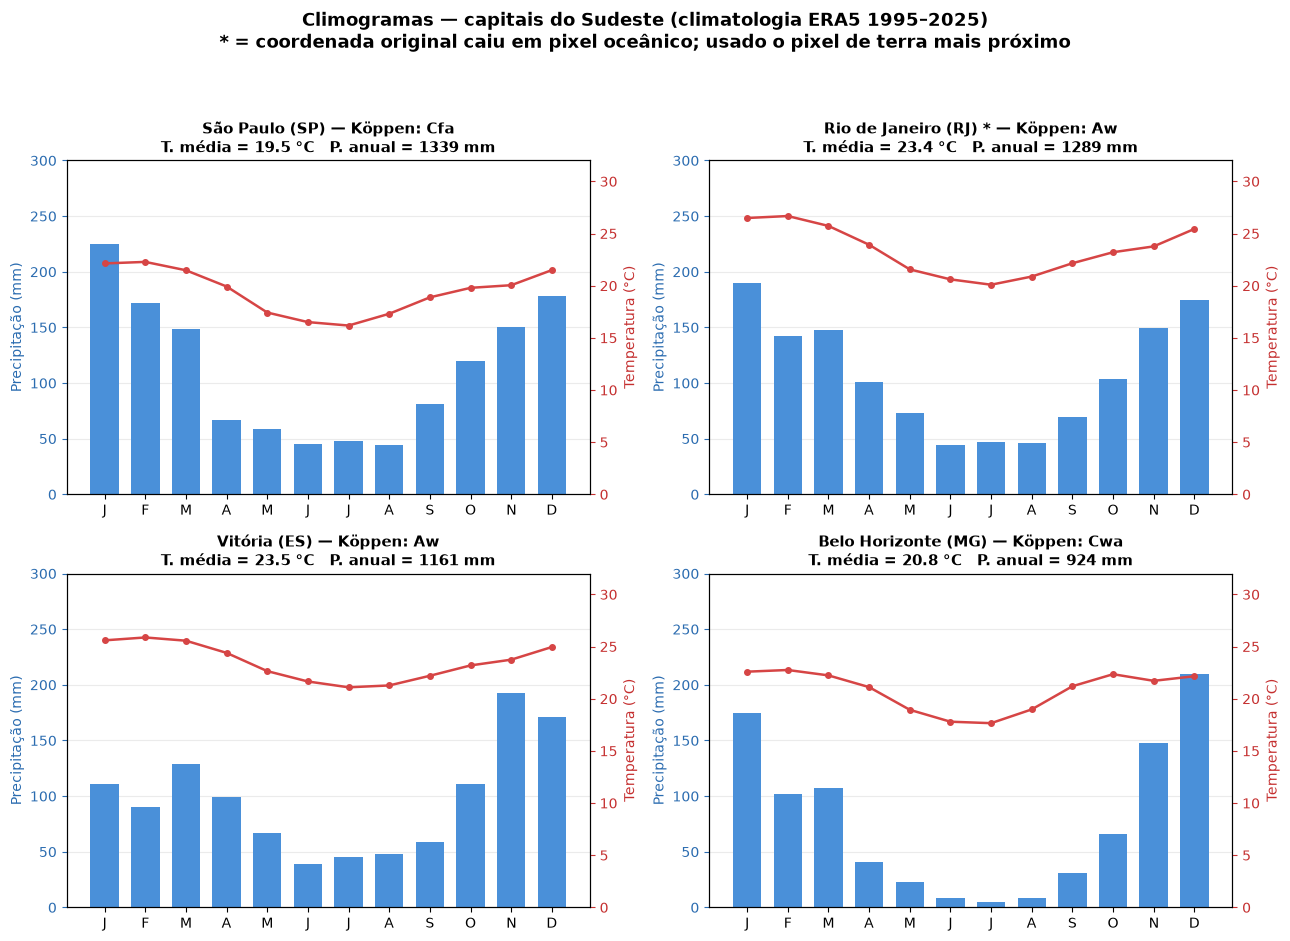

In [15]:
CLIMOGRAMA_LOCAIS = [
    ("São Paulo (SP)",      -23.55, -46.63),
    ("Rio de Janeiro (RJ)", -22.91, -43.17),
    ("Vitória (ES)",        -20.32, -40.31),
    ("Belo Horizonte (MG)", -19.92, -43.94),
]
MESES = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]


def pixel_terra_mais_proximo(lat, lon, janela=5):
    """Acha o índice (i, j) do pixel de terra válido mais próximo de (lat, lon).
    Cidades litorâneas (ex: Rio de Janeiro) podem cair num pixel oceânico
    (NA) na grade de 0.1°; nesse caso busca o vizinho de terra mais próximo
    numa janela de +-`janela` células."""
    i0 = int(np.abs(lats - lat).argmin())
    j0 = int(np.abs(lons - lon).argmin())
    if valid_mask[i0, j0]:
        return i0, j0
    melhor, melhor_dist = None, np.inf
    for di in range(-janela, janela + 1):
        for dj in range(-janela, janela + 1):
            i, j = i0 + di, j0 + dj
            if 0 <= i < len(lats) and 0 <= j < len(lons) and valid_mask[i, j]:
                dist = di ** 2 + dj ** 2
                if dist < melhor_dist:
                    melhor, melhor_dist = (i, j), dist
    if melhor is None:
        raise ValueError(f"nenhum pixel de terra a {janela} células de ({lat}, {lon})")
    return melhor


def plot_climograma(ax, nome, lat, lon):
    i, j = pixel_terra_mais_proximo(lat, lon)
    deslocado = (lats[i], lons[j]) != (lats[int(np.abs(lats - lat).argmin())],
                                        lons[int(np.abs(lons - lon).argmin())])
    p_local = p_vals[:, i, j]
    t_local = t_vals[:, i, j]
    clima_local = koppen_codes[i, j]

    ax2 = ax.twinx()
    ax.bar(range(12), p_local, color="#4a90d9", width=0.7, zorder=2)
    ax2.plot(range(12), t_local, color="#d64545", marker="o", ms=4, lw=1.8, zorder=3)

    ax.set_xticks(range(12))
    ax.set_xticklabels(MESES)
    ax.set_ylabel("Precipitação (mm)", color="#2b6cb0")
    ax2.set_ylabel("Temperatura (°C)", color="#c53030")
    ax.set_ylim(0, max(300, p_local.max() * 1.15))
    ax2.set_ylim(0, 32)
    ax.tick_params(axis="y", colors="#2b6cb0")
    ax2.tick_params(axis="y", colors="#c53030")
    ax.grid(axis="y", alpha=0.25, zorder=0)
    nota = " *" if deslocado else ""
    ax.set_title(f"{nome}{nota} — Köppen: {clima_local}\n"
                 f"T. média = {t_local.mean():.1f} °C   P. anual = {p_local.sum():.0f} mm",
                 fontsize=11, fontweight="bold")


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (nome, lat, lon) in zip(axes.flat, CLIMOGRAMA_LOCAIS):
    plot_climograma(ax, nome, lat, lon)

fig.suptitle("Climogramas — capitais do Sudeste (climatologia ERA5 1995–2025)\n"
             "* = coordenada original caiu em pixel oceânico; usado o pixel de terra mais próximo",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()
